In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
    )

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score,
    recall_score, f1_score, classification_report
    )

# 한글 폰트
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

SEED = 88

In [5]:
data = pd.read_excel('data/20250703_005327.xlsx')

In [6]:
df = pd.DataFrame(data)

In [7]:
df_original = df.copy(deep=True)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Columns: 307 entries, NO to 문44_01
dtypes: float64(255), int64(30), str(22)
memory usage: 5.9 MB


In [96]:
df_churn = df[df['GUBUN'] == 2]
df_churn.head()

,NO,확인 필요 사항,GUBUN,S1,S2,선문1,선문1_3_TXT,선문2_1,선문2_2,H선문2_01,H선문2,선문3,H선문3,배문1,배문2,배문3,배문4,배문4_9997_TXT,배문5,배문6,배문7,배문8,문1,문2_01,문2_01_9997_TXT,문2_02,문2_03,문2_03_9997_TXT,문3_1,문3_2,문3_3,문3_4,문3_5,문3_6,문3_7,문3_8,문3_9,문3_10,문3_11,문3_12,...,문20_10,문21,문22,문23_1,문23_2,문23_3,문23_4,문23_5,문23_6,문23_7,문23_8,문24_01_1,문24_02_1,문25_01,문25_02,문30_1,문31,문31_02_1,문31_02_2,문31_02_3,문31_02_4,문31_02_5,문31_02_6,문31_02_9997,문31_02_9997_TXT,문32,문32_01,문32_01_9997_TXT,문32_02,문32_02_9997_TXT,문33_1,문33_2,문33_3,문40,문41,문42,문43_01,문43_02,문44,문44_01
1,8,NaN,2,1,1,1,NaN,1977,10,47,4,9,2,4,2,1,3,NaN,1,12000000,3,4,2,3.0,NaN,1.0,4.0,NaN,NaN,NaN,3.0,NaN,NaN,NaN,7.0,NaN,NaN,10.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,1,1.0,NaN,NaN,NaN,2,2,2,2,NaN,1,1.0,3.0,1,2500000.0
5,64,NaN,2,1,1,1,NaN,1945,9,79,7,5,4,3,2,1,3,NaN,2,2500000,3,4,2,2.0,NaN,1.0,1.0,NaN,1.0,2.0,NaN,NaN,5.0,NaN,NaN,NaN,NaN,10.0,NaN,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1,1.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,1,1.0,NaN,NaN,NaN,1,2,2,2,NaN,1,2.0,NaN,1,300000.0
6,73,NaN,2,1,1,1,NaN,1963,9,61,6,9,2,4,2,1,1,NaN,1,3500000,2,3,2,2.0,NaN,1.0,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1,NaN,2.0,NaN,4.0,NaN,NaN,NaN,NaN,1,2.0,NaN,NaN,NaN,1,2,1,2,NaN,1,2.0,NaN,1,500000.0
7,82,월급(배문6) 응답 단위 확인 필요,2,1,1,1,NaN,1978,8,46,4,2,6,2,1,2,9998,NaN,1,270,2,4,2,3.0,NaN,1.0,9997.0,기부금 사용이 부실할까 우려되어,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.0,NaN,NaN,NaN,2,2,2,2,NaN,1,2.0,NaN,2,NaN
11,120,월급(배문6) 응답 단위 확인 필요,2,1,1,2,NaN,1984,11,40,4,16,6,4,1,2,9998,NaN,1,800,2,4,2,3.0,NaN,1.0,4.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1.0,NaN,NaN,NaN,1,1,1,1,5.0,1,2.0,NaN,2,NaN


In [ ]:
del_col = [
        'NO', '확인 필요 사항', 'S1', 'S2','선문1_3_TXT', '선문2_1', '선문2_2',
        'H선문2', '선문3', '배문4_9997_TXT', '문1', '문2_01', '문2_01_9997_TXT', 
        '문2_02', '문2_03', '문3_9997', '문3_9997_TXT', '문5_1', '문5_2', 
        '문7_9997_TXT', '문8_9997_TXT', '문9', '문10', '문11', '문11_9998', '문12',
        '문12_9998', '문2_03_9997_TXT',
]
for i in range(1, 23):
    if i < 11:
        del_col.append(f'문4_{i}_1')
        del_col.append(f'문20_{i}')
    elif i == 11:
        del_col.append(f'문4_{i-1}_TXT')

    if i <= 11:
        del_col.append(f'문4_01_{i}')

    if i <= 12:
        del_col.append(f'문4_02A_{i}')
        del_col.append(f'문4_02B_{i}')
        del_col.append(f'문4_02C_{i}')
        del_col.append(f'문4_02D_{i}')
        del_col.append(f'문4_02E_{i}')
        del_col.append(f'문4_02F_{i}')
        del_col.append(f'문4_02G_{i}')
        del_col.append(f'문4_02H_{i}')
    elif i == 13:
        del_col.append(f'문4_02A_{i-1}_TXT')
        del_col.append(f'문4_02B_{i-1}_TXT')
        del_col.append(f'문4_02C_{i-1}_TXT')
        del_col.append(f'문4_02D_{i-1}_TXT')
        del_col.append(f'문4_02E_{i-1}_TXT')
        del_col.append(f'문4_02F_{i-1}_TXT')
        del_col.append(f'문4_02G_{i-1}_TXT')
        del_col.append(f'문4_02H_{i-1}_TXT')
    if i < 20:
        del_col.append(f'문6_{i}')
        if i == 19:
            del_col.append(f'문6_{i}_TXT')

    if i <= 22:
        del_col.append(f'문13_01_{i}')
        del_col.append(f'문13_02_{i}')

    if i <= 13:
        del_col.append(f'문14_{i}')

    if i <= 8:
        del_col.append(f'문23_{i}')



del_col





['NO',
 '확인 필요 사항',
 'S1',
 'S2',
 '선문1_3_TXT',
 '선문2_1',
 '선문2_2',
 'H선문2',
 '선문3',
 '배문4_9997_TXT',
 '문1',
 '문2_01',
 '문2_01_9997_TXT',
 '문2_02',
 '문2_03',
 '문3_9997',
 '문3_9997_TXT',
 '문5_1',
 '문5_2',
 '문6_01',
 '문7_9997_TXT',
 '문8_9997_TXT',
 '문9',
 '문10',
 '문11',
 '문11_9998',
 '문12',
 '문12_9998',
 '문2_03_9997_TXT',
 '문4_1_1',
 '문20_1',
 '문4_01_1',
 '문4_02A_1',
 '문4_02B_1',
 '문4_02C_1',
 '문4_02D_1',
 '문4_02E_1',
 '문4_02F_1',
 '문4_02G_1',
 '문4_02H_1',
 '문6_1',
 '문13_01_1',
 '문13_02_1',
 '문14_1',
 '문23_1',
 '문4_2_1',
 '문20_2',
 '문4_01_2',
 '문4_02A_2',
 '문4_02B_2',
 '문4_02C_2',
 '문4_02D_2',
 '문4_02E_2',
 '문4_02F_2',
 '문4_02G_2',
 '문4_02H_2',
 '문6_2',
 '문13_01_2',
 '문13_02_2',
 '문14_2',
 '문23_2',
 '문4_3_1',
 '문20_3',
 '문4_01_3',
 '문4_02A_3',
 '문4_02B_3',
 '문4_02C_3',
 '문4_02D_3',
 '문4_02E_3',
 '문4_02F_3',
 '문4_02G_3',
 '문4_02H_3',
 '문6_3',
 '문13_01_3',
 '문13_02_3',
 '문14_3',
 '문23_3',
 '문4_4_1',
 '문20_4',
 '문4_01_4',
 '문4_02A_4',
 '문4_02B_4',
 '문4_02C_4',
 '문4_02D_4',
 '문4_02E_4',
 '문4

In [98]:
df_clean = df_churn.drop(columns=del_col).head(3)

In [99]:
df_clean = df_clean.loc[:, :'문8']
df_clean

,GUBUN,선문1,H선문2_01,H선문3,배문1,배문2,배문3,배문4,배문5,배문6,배문7,배문8,문3_1,문3_2,문3_3,문3_4,문3_5,문3_6,문3_7,문3_8,문3_9,문3_10,문3_11,문3_12,문7,문8
1,2,1,47,2,4,2,1,3,1,12000000,3,4,NaN,NaN,3.0,NaN,NaN,NaN,7.0,NaN,NaN,10.0,NaN,NaN,1.0,2.0
5,2,1,79,4,3,2,1,3,2,2500000,3,4,1.0,2.0,NaN,NaN,5.0,NaN,NaN,NaN,NaN,10.0,NaN,12.0,4.0,2.0
6,2,1,61,2,4,2,1,1,1,3500000,2,3,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0


In [106]:
cols = df_clean.loc[:,'문3_1' : '문3_12'].columns
df_clean[cols] = (df_clean[cols] >= 1).astype(int)
df_clean

,GUBUN,선문1,H선문2_01,H선문3,배문1,배문2,배문3,배문4,배문5,배문6,배문7,배문8,문3_1,문3_2,문3_3,문3_4,문3_5,문3_6,문3_7,문3_8,문3_9,문3_10,문3_11,문3_12,문7,문8
1,2,1,47,2,4,2,1,3,1,12000000,3,4,0,0,1,0,0,0,1,0,0,1,0,0,1.0,2.0
5,2,1,79,4,3,2,1,3,2,2500000,3,4,1,1,0,0,1,0,0,0,0,1,0,1,4.0,2.0
6,2,1,61,2,4,2,1,1,1,3500000,2,3,1,0,0,0,0,0,0,0,0,0,0,0,2.0,2.0


In [ ]:
df_clean['배문6_정리'] = np.where(df_clean['배문6'] >= 100_000, df_clean['배문6'] / 10000, df_clean['배문6'])
df_final = df_clean.drop(columns='배문6')


In [110]:
df_final = df_final.astype(int)
df_final

,GUBUN,선문1,H선문2_01,H선문3,배문1,배문2,배문3,배문4,배문5,배문7,배문8,문3_1,문3_2,문3_3,문3_4,문3_5,문3_6,문3_7,문3_8,문3_9,문3_10,문3_11,문3_12,문7,문8,배문6_정리
1,2,1,47,2,4,2,1,3,1,3,4,0,0,1,0,0,0,1,0,0,1,0,0,1,2,1200
5,2,1,79,4,3,2,1,3,2,3,4,1,1,0,0,1,0,0,0,0,1,0,1,4,2,250
6,2,1,61,2,4,2,1,1,1,2,3,1,0,0,0,0,0,0,0,0,0,0,0,2,2,350


In [90]:
df_clean

,GUBUN,선문1,H선문2_01,H선문3,배문1,배문2,배문3,배문4,배문5,배문6,배문7,배문8,문3_1,문3_2,문3_3,문3_4,문3_5,문3_6,문3_7,문3_8,문3_9,문3_10,문3_11,문3_12,문7,문8
1,2,1,47,2,4,2,1,3,1,12000000,3,4,0.0,0.0,3.0,0.0,0.0,0.0,7.0,0.0,0.0,10.0,0.0,0.0,1.0,2.0
5,2,1,79,4,3,2,1,3,2,2500000,3,4,1.0,2.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,10.0,0.0,12.0,4.0,2.0
6,2,1,61,2,4,2,1,1,1,3500000,2,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0


In [64]:
df_churn['문7_9997_TXT'].unique()

<StringArray>
[                            nan,                  '별다른 마음은 없었다.',
                        '남편세제혜택',                            '그냥',
                     '남는 돈이 있어서',                       '도움을 주려고',
           '한 두번 정도면 해보는 것도 좋아서', '우연히 알게되어서 그냥 해볼만하다고 생각했던 것 같다',
                       '물품이 예뻐서',              '좀 더 나은 사회가 되길바라며',
                    '학교에서 같이 해서',   '공식적인 모금이나 기부 행사에 참여를 독려 받아서',
           '포인트를 기부하는거라 부담이 없어서',                        '기회가되어서',
                      '그냥 하고싶어서',                         '딱히 없음',
                           '시켜서',                '초등학교에서 강제로 시켰음']
Length: 18, dtype: str

In [173]:
def get_data(df):

    df = df[df['GUBUN'] != 3]

    del_col = [
        'NO', '확인 필요 사항', 'S1', 'S2','선문1_3_TXT', '선문2_1', '선문2_2',
        'H선문2', '선문3', '배문4_9997_TXT', '문1', '문2_01', '문2_01_9997_TXT', 
        '문2_02', '문2_03', '문3_9997', '문3_9997_TXT', '문5_1', '문5_2', '문6_01',
        '문7_9997_TXT', '문8_9997_TXT', '문9', '문10', '문11', '문11_9998', '문12',
        '문12_9998', '문2_03_9997_TXT'
    ]
    # 지울 컬럼 추가 로직
    for i in range(1, 23):
        if i < 11:
            del_col.append(f'문4_{i}_1')
            del_col.append(f'문20_{i}')
        elif i == 11:
            del_col.append(f'문4_{i-1}_TXT')

        if i <= 11:
            del_col.append(f'문4_01_{i}')

        if i <= 12:
            del_col.append(f'문4_02A_{i}')
            del_col.append(f'문4_02B_{i}')
            del_col.append(f'문4_02C_{i}')
            del_col.append(f'문4_02D_{i}')
            del_col.append(f'문4_02E_{i}')
            del_col.append(f'문4_02F_{i}')
            del_col.append(f'문4_02G_{i}')
            del_col.append(f'문4_02H_{i}')
        elif i == 13:
            del_col.append(f'문4_02A_{i-1}_TXT')
            del_col.append(f'문4_02B_{i-1}_TXT')
            del_col.append(f'문4_02C_{i-1}_TXT')
            del_col.append(f'문4_02D_{i-1}_TXT')
            del_col.append(f'문4_02E_{i-1}_TXT')
            del_col.append(f'문4_02F_{i-1}_TXT')
            del_col.append(f'문4_02G_{i-1}_TXT')
            del_col.append(f'문4_02H_{i-1}_TXT')
        if i < 20:
            del_col.append(f'문6_{i}')
            if i == 19:
                del_col.append(f'문6_{i}_TXT')

        if i <= 22:
            del_col.append(f'문13_01_{i}')
            del_col.append(f'문13_02_{i}')

        if i <= 13:
            del_col.append(f'문14_{i}')

        if i <= 8:
            del_col.append(f'문23_{i}')

    df_clean = df.drop(columns=del_col)
    df_clean = df_clean.loc[:, :'문7']

    # 멀티 핫 인코딩 로직
    cols = df_clean.loc[:,'문3_1' : '문3_12'].columns
    df_clean[cols] = (df_clean[cols] >= 1).astype(int)

    # 종교없음 숫자 9998 배정된걸 0으로 변경
    df_clean['배문4'] = np.where(df_clean['배문4'] < 5, df_clean['배문4'], 0)

    # 단위 (만원) 에 맞추는 로직
    df_clean['배문6_정리'] = np.where(
        df_clean['배문6'] >= 100_000, 
        df_clean['배문6'] / 10000, df_clean['배문6']
    )

    df_clean['배문6_정리'] = np.log1p(df_clean['배문6_정리'])

    # 기타 항목 기존 비율대로 분배 하는 로직
    mask = df_clean['문7'] == 9997
    valid = df_clean.loc[df_clean['문7'].between(1, 5), '문7']
    probabilities = valid.value_counts(normalize=True).sort_index() # normalize 차지하는 비율로 계산

    rng = np.random.default_rng(SEED)


    df_clean.loc[mask, '문7'] = rng.choice(
        probabilities.index,    # 뽑을 후보 (1 ~ 5)
        size=mask.sum(),        # '9997' 개수 만큼 추출
        p=probabilities.values  # 기존 분포를 추출 확률로 사용
    )

    df_clean['문7'] = df_clean['문7'].fillna(0)
    
    df_final = df_clean.drop(columns='배문6')

    return df_final

In [134]:
df_final = get_data(df)

In [135]:
df_final

,GUBUN,선문1,H선문2_01,H선문3,배문1,배문2,배문3,배문4,배문5,배문7,...,문3_5,문3_6,문3_7,문3_8,문3_9,문3_10,문3_11,문3_12,문7,배문6_정리
0,1,2,52,2,4,2,1,0,2,2,...,0,0,0,0,0,1,0,0,4.0,6.111467
1,2,1,47,2,4,2,1,3,1,3,...,0,0,1,0,0,1,0,0,1.0,7.090910
2,1,2,68,1,2,2,1,3,2,2,...,1,0,0,0,0,0,0,0,4.0,6.111467
3,1,1,41,7,4,2,1,0,1,3,...,1,0,0,0,0,0,0,0,2.0,6.803505
4,1,2,61,1,3,1,2,0,8,1,...,1,0,0,0,0,0,0,0,1.0,5.525453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,1,2,70,4,3,2,1,1,6,3,...,0,0,0,0,0,0,0,0,1.0,6.175867
2496,1,1,73,4,2,2,1,1,8,2,...,0,0,1,0,0,0,0,0,2.0,5.707110
2497,1,2,72,2,2,2,1,1,1,2,...,0,0,1,0,0,1,0,0,1.0,6.216606
2498,2,1,77,4,4,2,1,0,8,1,...,0,0,1,0,0,0,0,0,2.0,6.111467


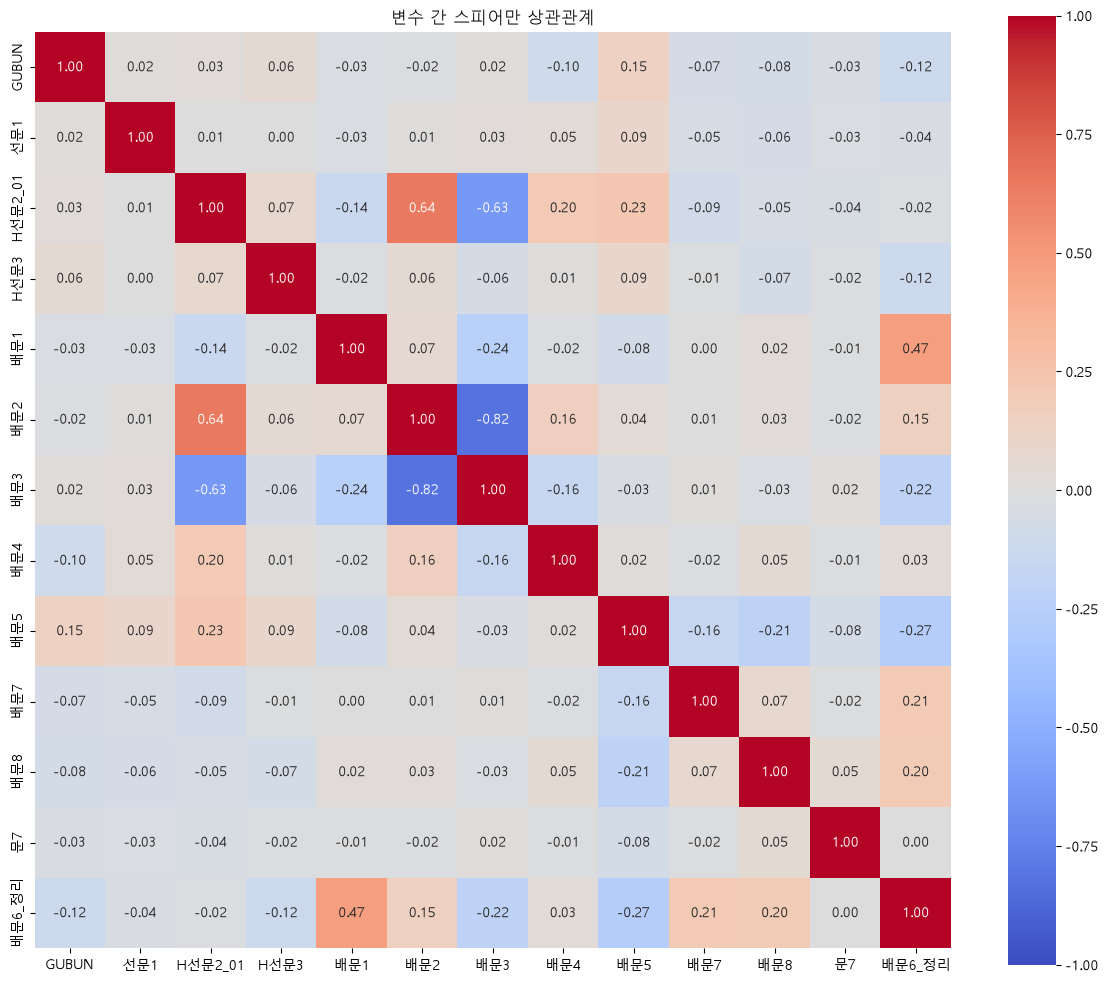

In [136]:
cols = [
    'GUBUN', '선문1', 'H선문2_01', 'H선문3',
    '배문1', '배문2', '배문3', '배문4',
    '배문5', '배문7', '배문8', '문7', '배문6_정리'
]

corr = df_final[cols].corr(method='spearman')

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True
)

plt.title('변수 간 스피어만 상관관계')
plt.tight_layout()
plt.show()

In [266]:
X = df_final.drop(columns='GUBUN')
y = df_final['GUBUN']

In [267]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    stratify = y,
    random_state = SEED
)

print(len(X_train), len(X_test), len(y_train), len(y_test))

1611 403 1611 403


In [268]:
rf_model = RandomForestClassifier(random_state=SEED, n_jobs=-1)

rf_model.fit(X_train, y_train)

rf_pred_train = rf_model.predict(X_train)
rf_pred_test = rf_model.predict(X_test)
# print(f'학습 정확도 : {accuracy_score(y_train, rf_pred_train)}')
# print(f'학습 정밀도 : {precision_score(y_train, rf_pred_train)}')
# print(f'학습 재현율 : {recall_score(y_train, rf_pred_train)}')
# print(f'학습 f-1 : {f1_score(y_train, rf_pred_train)}')
# print('-' * 50)
# print(f'테스트 정확도 : {accuracy_score(y_test, rf_pred_test)}')
# print(f'테스트 정밀도 : {precision_score(y_test, rf_pred_test)}')
# print(f'테스트 재현율 : {recall_score(y_test, rf_pred_test)}')
# print(f'테스트 f-1 : {f1_score(y_test, rf_pred_test)}')

print(classification_report(y_train, rf_pred_train, zero_division=0))
print(classification_report(y_test, rf_pred_test, zero_division=0))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1195
           2       1.00      1.00      1.00       416

    accuracy                           1.00      1611
   macro avg       1.00      1.00      1.00      1611
weighted avg       1.00      1.00      1.00      1611

              precision    recall  f1-score   support

           1       0.76      0.97      0.85       299
           2       0.60      0.12      0.19       104

    accuracy                           0.75       403
   macro avg       0.68      0.54      0.52       403
weighted avg       0.72      0.75      0.68       403



In [269]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth' : [2, 3, 5, 10],
    'min_samples_split' : [2, 3, 5],
    'min_samples_leaf' : [1, 5, 8],
    'class_weight': ['balanced', 'balanced_subsample']
}

grid = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    ),
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
{'class_weight': 'balanced_subsample', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
0.6022798863291565


In [270]:
grid_best_params = grid.best_params_

In [271]:
orf_model = RandomForestClassifier(**grid_best_params)

orf_model.fit(X_train, y_train)

orf_pred_train = orf_model.predict(X_train)
orf_pred_test = orf_model.predict(X_test)

print(classification_report(y_train, orf_pred_train, zero_division=0))
print(classification_report(y_test, orf_pred_test, zero_division=0))

              precision    recall  f1-score   support

           1       0.87      0.75      0.81      1195
           2       0.49      0.69      0.57       416

    accuracy                           0.73      1611
   macro avg       0.68      0.72      0.69      1611
weighted avg       0.77      0.73      0.75      1611

              precision    recall  f1-score   support

           1       0.81      0.75      0.78       299
           2       0.41      0.51      0.46       104

    accuracy                           0.69       403
   macro avg       0.61      0.63      0.62       403
weighted avg       0.71      0.69      0.70       403



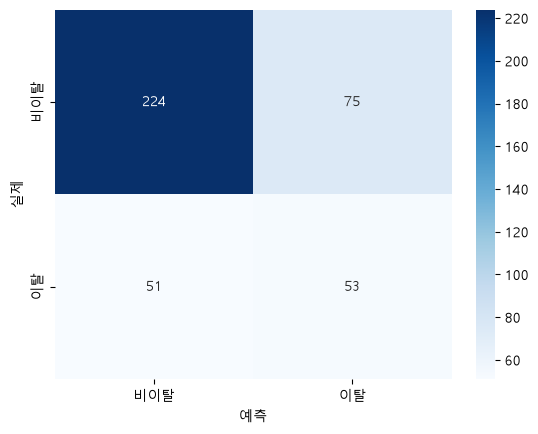

In [272]:
cm = confusion_matrix(y_test, orf_pred_test)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['비이탈', '이탈'],
    yticklabels=['비이탈', '이탈']
)

plt.xlabel('예측')
plt.ylabel('실제')
plt.show()

In [273]:
param_distributions = {
    'n_estimators': [100, 200],
    'max_depth' : [2, 3, 5, 10],
    'min_samples_split' : [2, 3, 5],
    'min_samples_leaf' : [1, 5, 8],
    'class_weight': ['balanced', 'balanced_subsample']
}

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='f1_macro',
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    ),
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)
print(random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_depth': 10, 'class_weight': 'balanced'}
0.6002273373291336


In [274]:
rs_best_params = random_search.best_params_

In [275]:
arf_model = RandomForestClassifier(**rs_best_params)

arf_model.fit(X_train, y_train)

arf_pred_train = arf_model.predict(X_train)
arf_pred_test = arf_model.predict(X_test)

print(classification_report(y_train, arf_pred_train, zero_division=0))
print(classification_report(y_test, arf_pred_test, zero_division=0))

              precision    recall  f1-score   support

           1       0.92      0.76      0.83      1195
           2       0.54      0.81      0.65       416

    accuracy                           0.77      1611
   macro avg       0.73      0.79      0.74      1611
weighted avg       0.82      0.77      0.78      1611

              precision    recall  f1-score   support

           1       0.81      0.74      0.77       299
           2       0.41      0.52      0.46       104

    accuracy                           0.68       403
   macro avg       0.61      0.63      0.61       403
weighted avg       0.71      0.68      0.69       403



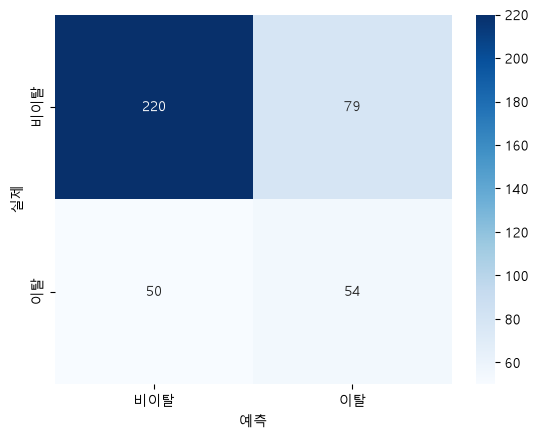

In [276]:
cm = confusion_matrix(y_test, arf_pred_test)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['비이탈', '이탈'],
    yticklabels=['비이탈', '이탈']
)

plt.xlabel('예측')
plt.ylabel('실제')
plt.show()

GridseachCV보다 RandomizesearchCV가 더 최적화 성능이 좋은것으로 보아 rcv를 메인 최적화로 가져간다.

In [148]:
param_distributions = {
    'C': np.logspace(-3, 3, 30),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced'],
    'max_iter': [1000, 2000, 3000]
}

lr_model = LogisticRegression(random_state=SEED)

random_search = RandomizedSearchCV(
    estimator=lr_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='f1_macro',
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    ),
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

lr_best_params = random_search.best_params_
alr_model = random_search.best_estimator_

alr_pred_train = alr_model.predict(X_train)
alr_pred_test = alr_model.predict(X_test)

print(lr_best_params)
print(f'최고 교차검증 F1-macro: {random_search.best_score_:.4f}')

print(classification_report(y_train, alr_pred_train, zero_division=0))
print(classification_report(y_test, alr_pred_test, zero_division=0))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 2000, 'class_weight': 'balanced', 'C': np.float64(0.02807216203941177)}
최고 교차검증 F1-macro: 0.5805
              precision    recall  f1-score   support

           1       0.83      0.65      0.73      1195
           2       0.38      0.62      0.47       416

    accuracy                           0.64      1611
   macro avg       0.61      0.64      0.60      1611
weighted avg       0.72      0.64      0.66      1611

              precision    recall  f1-score   support

           1       0.80      0.62      0.70       299
           2       0.34      0.55      0.42       104

    accuracy                           0.60       403
   macro avg       0.57      0.59      0.56       403
weighted avg       0.68      0.60      0.63       403



c:\Users\playdata2\2nd_project\SKN34-2nd-6Team\basic_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


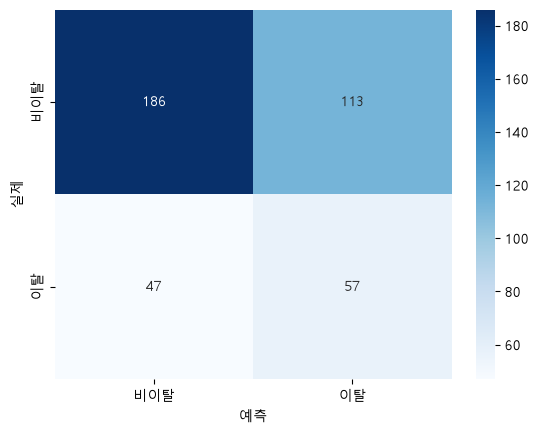

In [149]:
cm = confusion_matrix(y_test, alr_pred_test)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['비이탈', '이탈'],
    yticklabels=['비이탈', '이탈']
)

plt.xlabel('예측')
plt.ylabel('실제')
plt.show()

In [150]:
param_distributions = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [1, 2, 3],
    'min_samples_split': [10, 20, 30, 50],
    'min_samples_leaf': [5, 10, 20, 30],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'max_features': ['sqrt', 'log2', 0.5],
    'n_iter_no_change': [5, 10],
    'validation_fraction': [0.1, 0.2]
}

grb_model = GradientBoostingClassifier(random_state=SEED)

random_search = RandomizedSearchCV(
    estimator=grb_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='f1_macro',
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    ),
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

grb_best_params = random_search.best_params_
agrb_model = random_search.best_estimator_

agrb_pred_train = agrb_model.predict(X_train)
agrb_pred_test = agrb_model.predict(X_test)

print(classification_report(y_train, agrb_pred_train, zero_division=0))
print(classification_report(y_test, agrb_pred_test, zero_division=0))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
              precision    recall  f1-score   support

           1       0.76      0.98      0.86      1195
           2       0.69      0.11      0.19       416

    accuracy                           0.76      1611
   macro avg       0.73      0.55      0.52      1611
weighted avg       0.74      0.76      0.68      1611

              precision    recall  f1-score   support

           1       0.75      0.98      0.85       299
           2       0.46      0.06      0.10       104

    accuracy                           0.74       403
   macro avg       0.61      0.52      0.48       403
weighted avg       0.67      0.74      0.66       403



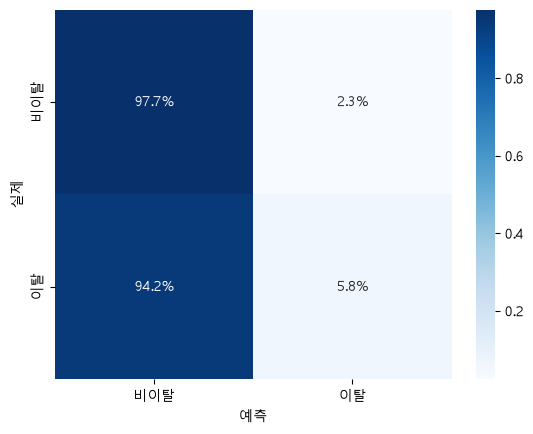

In [151]:
cm = confusion_matrix(
    y_test,
    agrb_pred_test,
    labels=[1, 2],
    normalize='true'
)

sns.heatmap(
    cm,
    annot=True,
    fmt='.1%',
    cmap='Blues',
    xticklabels=['비이탈', '이탈'],
    yticklabels=['비이탈', '이탈']
)

plt.xlabel('예측')
plt.ylabel('실제')
plt.show()

In [168]:
# XGBoost는 이진분류 정답을 0과 1로 사용
y_train_xgb = (y_train == 2).astype(int)
y_test_xgb = (y_test == 2).astype(int)

imbalance_ratio = (y_train_xgb == 0).sum() / (y_train_xgb == 1).sum()

param_distributions = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.85, 1.0],
    'scale_pos_weight': [1.0, imbalance_ratio, imbalance_ratio * 1.5]
}

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=SEED,
    n_jobs=1
)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='f1_macro',
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    ),
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train_xgb)

xgb_best_params = random_search.best_params_
axgb_model = random_search.best_estimator_

# 평가를 위해 0·1 예측을 기존 GUBUN 값 1·2로 복원
axgb_pred_train = axgb_model.predict(X_train) + 1
axgb_pred_test = axgb_model.predict(X_test) + 1

threshold = 0.48

train_proba = axgb_model.predict_proba(X_train)[:, 1]
test_proba = axgb_model.predict_proba(X_test)[:,1]

axgb_pred_train = np.where(
    train_proba >= threshold,
    2, 1
)

axgb_pred_test = np.where(
    test_proba >= threshold,
    2, 1
)

print(xgb_best_params)
print(f'최고 교차검증 F1-macro: {random_search.best_score_:.4f}')

print(classification_report(y_train, axgb_pred_train, zero_division=0))
print(classification_report(y_test, axgb_pred_test, zero_division=0))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'subsample': 1.0, 'scale_pos_weight': np.float64(2.8725961538461537), 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 2, 'learning_rate': 0.05}
최고 교차검증 F1-macro: 0.5922
              precision    recall  f1-score   support

           1       0.88      0.59      0.70      1195
           2       0.39      0.76      0.52       416

    accuracy                           0.63      1611
   macro avg       0.63      0.68      0.61      1611
weighted avg       0.75      0.63      0.66      1611

              precision    recall  f1-score   support

           1       0.82      0.60      0.69       299
           2       0.35      0.63      0.46       104

    accuracy                           0.61       403
   macro avg       0.59      0.62      0.57       403
weighted avg       0.70      0.61      0.63       403



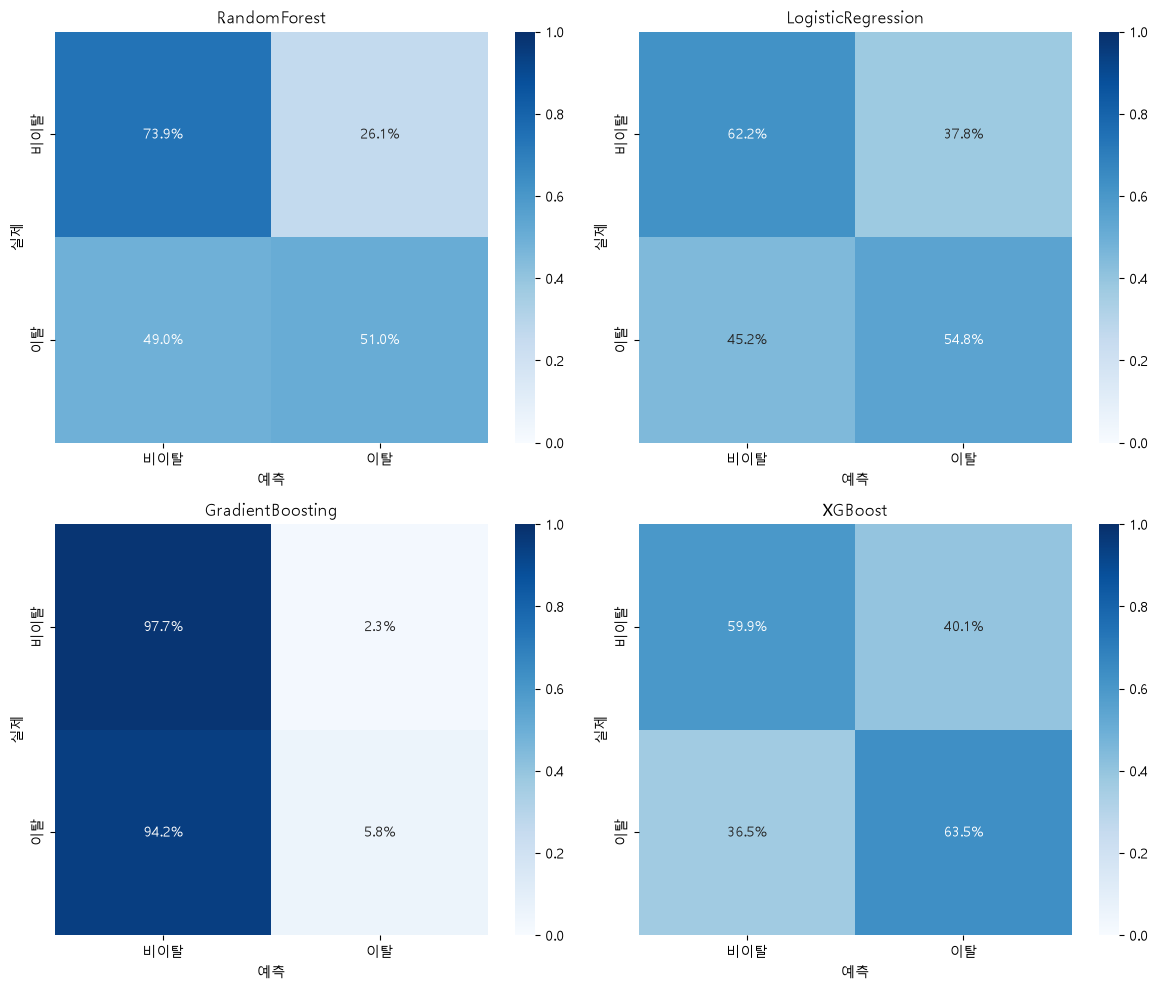

In [171]:
models = [
    ('RandomForest', arf_pred_test), 
    ('LogisticRegression', alr_pred_test), 
    ('GradientBoosting', agrb_pred_test), 
    ('XGBoost', axgb_pred_test)
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, model) in zip(axes.flatten(), models):
    cm = confusion_matrix(
        y_test,
        model,
        labels=[1, 2],
        normalize='true'
    )

    
    sns.heatmap(
        cm,
        ax=ax,
        annot=True,
        fmt='.1%',
        cmap='Blues',
        vmin=0,
        vmax=1,
        xticklabels=['비이탈', '이탈'],
        yticklabels=['비이탈', '이탈']
    )

    ax.set_title(name)
    ax.set_xlabel('예측')
    ax.set_ylabel('실제')

plt.tight_layout()
plt.show()

In [16]:
def get_model(df):

    X = df.drop(columns='GUBUN')
    y = df['GUBUN']

    X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    stratify = y,
    random_state = SEED
    )


    # XGBoost는 이진분류 정답을 0과 1로 사용
    y_train_xgb = (y_train == 2).astype(int)
    y_test_xgb = (y_test == 2).astype(int)

    imbalance_ratio = (y_train_xgb == 0).sum() / (y_train_xgb == 1).sum()

    param_distributions = {
        'n_estimators': [50, 100, 150, 200],
        'learning_rate': [0.03, 0.05, 0.1],
        'max_depth': [1, 2, 3],
        'min_child_weight': [3, 5, 10],
        'subsample': [0.6, 0.75, 0.9],
        'scale_pos_weight': [1.0, imbalance_ratio, imbalance_ratio * 1.5]
    }

    xgb_model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',

        reg_alpha = 0.1,
        reg_lambda = 3.0,
        colsample_bytree = 0.8,
        random_state=SEED,
        n_jobs=1
    )

    random_search = RandomizedSearchCV(
        estimator=xgb_model,
        param_distributions=param_distributions,
        n_iter=20,
        scoring='f1_macro',
        cv=StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=SEED
        ),
        random_state=SEED,
        n_jobs=-1,
        verbose=1
    )

    random_search.fit(X_train, y_train_xgb)

    axgb_model = random_search.best_estimator_

    # 평가를 위해 0·1 예측을 기존 GUBUN 값 1·2로 복원
    axgb_pred_train = axgb_model.predict(X_train) + 1
    axgb_pred_test = axgb_model.predict(X_test) + 1

    # threshold = 0.475

    # train_proba = axgb_model.predict_proba(X_train)[:, 1]
    # test_proba = axgb_model.predict_proba(X_test)[:,1]

    # axgb_pred_train = np.where(
    #     train_proba >= threshold,
    #     2, 1
    # )

    # axgb_pred_test = np.where(
    #     test_proba >= threshold,
    #     2, 1
    # )


    train_report = classification_report(y_train, axgb_pred_train, zero_division=0)
    test_report = classification_report(y_test, axgb_pred_test, zero_division=0)

    return axgb_model, train_report, test_report, axgb_pred_test, y_test

In [10]:
def get_data_v2(df):

    df = df[df['GUBUN'] != 3]

    del_col = [
        'NO', '확인 필요 사항', 'S1', 'S2','선문1_3_TXT', '선문2_1', '선문2_2',
        'H선문2', '선문3', '배문4_9997_TXT', '문1', '문2_01', '문2_01_9997_TXT', 
        '문2_02', '문2_03', '문3_9997', '문3_9997_TXT', '문5_1', '문5_2',
        '문7_9997_TXT', '문8_9997_TXT', '문9', '문10', '문11', '문11_9998', '문12',
        '문12_9998', '문2_03_9997_TXT'
    ]
    # 지울 컬럼 추가 로직
    for i in range(1, 23):
        if i < 11:
            del_col.append(f'문4_{i}_1')
            del_col.append(f'문20_{i}')
        elif i == 11:
            del_col.append(f'문4_{i-1}_TXT')

        if i <= 11:
            del_col.append(f'문4_01_{i}')

        if i <= 12:
            del_col.append(f'문4_02A_{i}')
            del_col.append(f'문4_02B_{i}')
            del_col.append(f'문4_02C_{i}')
            del_col.append(f'문4_02D_{i}')
            del_col.append(f'문4_02E_{i}')
            del_col.append(f'문4_02F_{i}')
            del_col.append(f'문4_02G_{i}')
            del_col.append(f'문4_02H_{i}')
        elif i == 13:
            del_col.append(f'문4_02A_{i-1}_TXT')
            del_col.append(f'문4_02B_{i-1}_TXT')
            del_col.append(f'문4_02C_{i-1}_TXT')
            del_col.append(f'문4_02D_{i-1}_TXT')
            del_col.append(f'문4_02E_{i-1}_TXT')
            del_col.append(f'문4_02F_{i-1}_TXT')
            del_col.append(f'문4_02G_{i-1}_TXT')
            del_col.append(f'문4_02H_{i-1}_TXT')
        if i < 20:
            del_col.append(f'문6_{i}')
            if i == 19:
                del_col.append(f'문6_{i}_TXT')

        if i <= 22:
            del_col.append(f'문13_01_{i}')
            del_col.append(f'문13_02_{i}')

        if i <= 13:
            del_col.append(f'문14_{i}')

        if i <= 8:
            del_col.append(f'문23_{i}')

    df_clean = df.drop(columns=del_col)
    # df_clean = df_clean.loc[:, :'문7']
    df_clean = df_clean[df_clean.loc[:, :'문7'].columns.tolist() + ['문40', '문42']]

    # 멀티 핫 인코딩 로직
    cols = df_clean.loc[:,'문3_1' : '문3_12'].columns
    df_clean[cols] = (df_clean[cols] >= 1).astype(int)

    # 종교없음 숫자 9998 배정된걸 0으로 변경
    df_clean['배문4'] = np.where(df_clean['배문4'] < 5, df_clean['배문4'], 0)

    # 단위 (만원) 에 맞추는 로직
    df_clean['배문6_정리'] = np.where(
        df_clean['배문6'] >= 100_000, 
        df_clean['배문6'] / 10000, df_clean['배문6']
    )

    df_clean['배문6_정리'] = np.log1p(df_clean['배문6_정리'])

    # 기타 항목 기존 비율대로 분배 하는 로직
    mask = df_clean['문7'] == 9997
    valid = df_clean.loc[df_clean['문7'].between(1, 5), '문7']
    probabilities = valid.value_counts(normalize=True).sort_index() # normalize 차지하는 비율로 계산

    rng = np.random.default_rng(SEED)


    df_clean.loc[mask, '문7'] = rng.choice(
        probabilities.index,    # 뽑을 후보 (1 ~ 5)
        size=mask.sum(),        # '9997' 개수 만큼 추출
        p=probabilities.values  # 기존 분포를 추출 확률로 사용
    )

    df_clean['문7'] = df_clean['문7'].fillna(0)
    

    return df_clean.drop(columns='배문6')

In [11]:
df_other = get_data_v2(df)
df_other

,GUBUN,선문1,H선문2_01,H선문3,배문1,배문2,배문3,배문4,배문5,배문7,...,문3_8,문3_9,문3_10,문3_11,문3_12,문6_01,문7,문40,문42,배문6_정리
0,1,2,52,2,4,2,1,0,2,2,...,0,0,1,0,0,10000.0,4.0,2,1,6.111467
1,2,1,47,2,4,2,1,3,1,3,...,0,0,1,0,0,NaN,1.0,2,1,7.090910
2,1,2,68,1,2,2,1,3,2,2,...,0,0,0,0,0,3000.0,4.0,2,1,6.111467
3,1,1,41,7,4,2,1,0,1,3,...,0,0,0,0,0,150000.0,2.0,2,1,6.803505
4,1,2,61,1,3,1,2,0,8,1,...,0,0,0,0,0,NaN,1.0,2,2,5.525453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,1,2,70,4,3,2,1,1,6,3,...,0,0,0,0,0,NaN,1.0,2,1,6.175867
2496,1,1,73,4,2,2,1,1,8,2,...,0,0,0,0,0,NaN,2.0,2,1,5.707110
2497,1,2,72,2,2,2,1,1,1,2,...,0,0,1,0,0,NaN,1.0,2,1,6.216606
2498,2,1,77,4,4,2,1,0,8,1,...,0,0,0,0,0,NaN,2.0,1,1,6.111467


In [12]:
df_clear = df_other.fillna(0)

In [17]:
axgb_model, train_report, test_report, oxgb_pred_test, y_test = get_model(df_clear)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [18]:
print(train_report)
print(test_report)

              precision    recall  f1-score   support

           1       0.94      0.65      0.77      1195
           2       0.47      0.88      0.61       416

    accuracy                           0.71      1611
   macro avg       0.71      0.77      0.69      1611
weighted avg       0.82      0.71      0.73      1611

              precision    recall  f1-score   support

           1       0.88      0.62      0.73       299
           2       0.41      0.76      0.53       104

    accuracy                           0.66       403
   macro avg       0.65      0.69      0.63       403
weighted avg       0.76      0.66      0.68       403



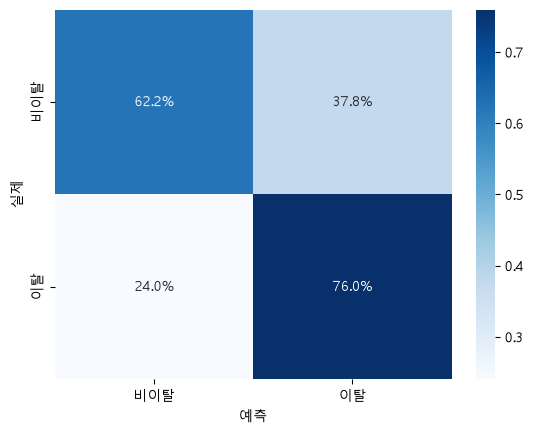

In [19]:
cm = confusion_matrix(
    y_test,
    oxgb_pred_test,
    labels=[1, 2],
    normalize='true'
)

sns.heatmap(
    cm,
    annot=True,
    fmt='.1%',
    cmap='Blues',
    xticklabels=['비이탈', '이탈'],
    yticklabels=['비이탈', '이탈']
)

plt.xlabel('예측')
plt.ylabel('실제')
plt.show()

In [254]:
print(accuracy_score(y_test, oxgb_pred_test))

0.6575682382133995


In [206]:
from catboost import CatBoostClassifier

def get_model_cat(df):

    X = df.drop(columns='GUBUN')
    y = df['GUBUN']

    X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    stratify = y,
    random_state = SEED
    )



    param_distributions = {
        'iterations': [100, 200, 300, 500],
        'depth': [3, 4, 5, 6],
        'learning_rate': [0.01, 0.03, 0.05, 0.1],
        'l2_leaf_reg': [1, 3, 5, 10],
        'random_strength': [0.5, 1, 2, 5],
        'border_count': [32, 64, 128]
    }

    cat_model = CatBoostClassifier(
        loss_function='Logloss',
        eval_metric='F1',
        auto_class_weights='Balanced',
        random_seed = SEED,
        verbose=0
    )

    random_search = RandomizedSearchCV(
        estimator=cat_model,
        param_distributions=param_distributions,
        n_iter=20,
        scoring='f1_macro',
        cv=StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=SEED
        ),
        random_state=SEED,
        n_jobs=-1,
        verbose=1
    )

    random_search.fit(X_train, y_train)

    ocat_model = random_search.best_estimator_

    cat_pred_train = ocat_model.predict(X_train)
    cat_pred_test = ocat_model.predict(X_test)


    # threshold = 0.48

    # train_proba = axgb_model.predict_proba(X_train)[:, 1]
    # test_proba = axgb_model.predict_proba(X_test)[:,1]

    # axgb_pred_train = np.where(
    #     train_proba >= threshold,
    #     2, 1
    # )

    # axgb_pred_test = np.where(
    #     test_proba >= threshold,
    #     2, 1
    # )


    train_report = classification_report(y_train, cat_pred_train, zero_division=0)
    test_report = classification_report(y_test, cat_pred_test, zero_division=0)

    return ocat_model, train_report, test_report, cat_pred_test

In [207]:
ocat_model, train_report, test_report, cat_pred_test = get_model_cat(df_clear)

print(train_report)
print(test_report)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
              precision    recall  f1-score   support

           1       1.00      0.83      0.91      1195
           2       0.67      0.99      0.80       416

    accuracy                           0.87      1611
   macro avg       0.83      0.91      0.85      1611
weighted avg       0.91      0.87      0.88      1611

              precision    recall  f1-score   support

           1       0.85      0.71      0.78       299
           2       0.44      0.65      0.53       104

    accuracy                           0.69       403
   macro avg       0.65      0.68      0.65       403
weighted avg       0.75      0.69      0.71       403



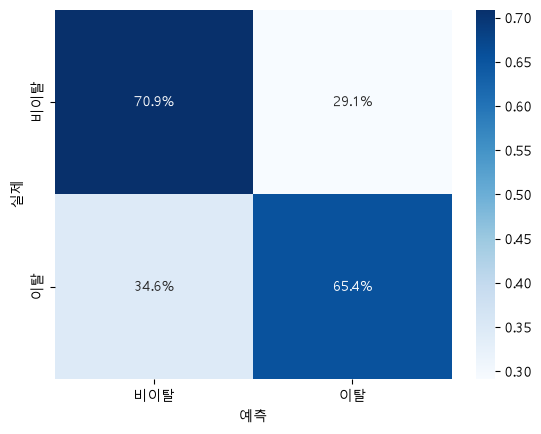

In [211]:
cm = confusion_matrix(
    y_test,
    cat_pred_test,
    labels=[1, 2],
    normalize='true'
)

sns.heatmap(
    cm,
    annot=True,
    fmt='.1%',
    cmap='Blues',
    xticklabels=['비이탈', '이탈'],
    yticklabels=['비이탈', '이탈']
)

plt.xlabel('예측')
plt.ylabel('실제')
plt.show()

In [20]:
from joblib import dump, load

dump(axgb_model, 'XGBoost_model_v1.joblib')

['XGBoost_model_v1.joblib']